In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dill
import numpy as np
import os
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split, HalvingGridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearnex.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import joblib
from datetime import datetime

cur_dir = os.getcwd()

Preprocessing pipeline from previous section is used for data preprocessing.

In [2]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

with open(cur_dir + '\\saves\\preprocessing_pipeline.dill', 'rb') as file:
    pipe = dill.load(file)

df = pipe.transform(df)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1, stratify=y)

Data obtained during evaluation of different resampling methods from previous section is used as "0" iteration for hyperparameters tuning.

In [3]:
try:
    stats = joblib.load(cur_dir + '\\saves\\models_training.pkl')
except:
    stats = pd.DataFrame(columns=['model', 'iteration', 'f1_train', 'f1_test', 'accuracy_test'])

    scores = joblib.load(cur_dir + '\\saves\\resampling_selection.pkl')
    train_scores = scores['train_scores']
    train_scores = train_scores[train_scores['sampler'] == 'NoResampling']
    test_scores = scores['test_scores']
    test_scores = test_scores[test_scores['sampler'] == 'NoResampling']

    for model_name in ['Nearest Neighbor', 'Decision Tree', 'Random Forest', 'MLPC']:
        f1_train = train_scores.loc[train_scores['model'] == model_name, 'value'].mean()
        f1_test = test_scores.loc[(test_scores['model'] == model_name) & (test_scores['metric'] == 'f1'), 'value'].item()
        accuracy = test_scores.loc[(test_scores['model'] == model_name) & (test_scores['metric'] == 'accuracy'), 'value'].item()
        stats.loc[len(stats.index)] = {'model': model_name, 'iteration': 0, 'f1_train': f1_train, 'f1_test': f1_test, 'accuracy_test': accuracy}

The function below is used for searching for hyperparameters search in two modes: HalvingGridSearchCV and GridSearchCV

In [92]:
def gs_cv(model_name, iteration, model, params, n_jobs=10, search_type='halving'):
    if stats[(stats['model'] == model_name) & (stats['iteration'] == iteration)].shape[0] > 0:
        raise ValueError('Search with this same name already exists')  # in case the search iteration with same number was already recorded, kindly show an error

    start = datetime.now()
    cv = RepeatedStratifiedKFold(random_state=1)  # to prevent overfitting on train data

    if search_type == 'grid':
        gs = GridSearchCV(model, cv=cv, param_grid=params, scoring='f1', n_jobs=n_jobs, verbose=2)
    else:
        gs = HalvingGridSearchCV(model, cv=cv, param_grid=params, scoring='f1', n_jobs=n_jobs, aggressive_elimination=True, verbose=2)
        
    gs.fit(X_train, y_train)
    print('Best params:', gs.best_params_)
    
    pred = gs.predict(X_test)
    # iteration's data is stored
    stats.loc[len(stats.index)] = [model_name, iteration, gs.best_score_, f1_score(y_test, pred), accuracy_score(y_test, pred)]
    joblib.dump(stats, cur_dir + '\\saves\\models_training.pkl')
    joblib.dump(gs, cur_dir + '\\saves\\models_training\\' + model_name + '_' + str(iteration) + '.pkl')  # whole GridSearch is saved to store best_estimator_ and training scores
    
    print('\nTime:', (datetime.now() - start).seconds /60 /60)  # hours
    print('Best params:', gs.best_params_)

    print('Train set f1:', stats.loc[len(stats.index)-1, 'f1_train'])
    print('Test set f1:', stats.loc[len(stats.index)-1, 'f1_test'])
    
    print('Test set accuracy:', stats.loc[len(stats.index)-1, 'accuracy_test'])

    return gs

Function below plots train and test scores for all iterations, selects best result and calculates confusion matrix and classification report.

In [5]:
def tuneplot(model_name):
    ax = sns.lineplot(data=stats[stats['model'] == model_name], x='iteration', y='f1_test', label='Test')
    sns.lineplot(data=stats[stats['model'] == model_name], x='iteration', y='f1_train', label='Train', color='g')

    max_test_score = stats.loc[stats['model'] == model_name, 'f1_test'].max()
    best_iteration = stats.loc[(stats['model'] == model_name) & (stats['f1_test'] == max_test_score), 'iteration'].iloc[0]
    plt.axvline(x=best_iteration, color='r', linestyle=':')  # marking best score
    
    ax.set_title(model_name + ' f1 score over hyperparameters tuning iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('F1 score')
    
    ax.set_xticks(range(0, stats[stats['model'] == model_name].shape[0]))  # to remove decimal ticks
    ax.legend(loc='upper right')
    #ax.legend(bbox_to_anchor=(1, 1))
    plt.show()

    best_model = joblib.load(cur_dir + '\\saves\\models_training\\' + model_name + '_' + str(best_iteration) + '.pkl').best_estimator_
    pred = best_model.predict(X_test)

    print('Confusion matrix:')
    print(confusion_matrix(y_test, pred), '\n')
    print('Classification report:')
    print(classification_report(y_test, pred, target_names=['Not fraud', 'Fraud']))

This is baseline for further tuning.</br>
These are scores obtained for models with default setting.

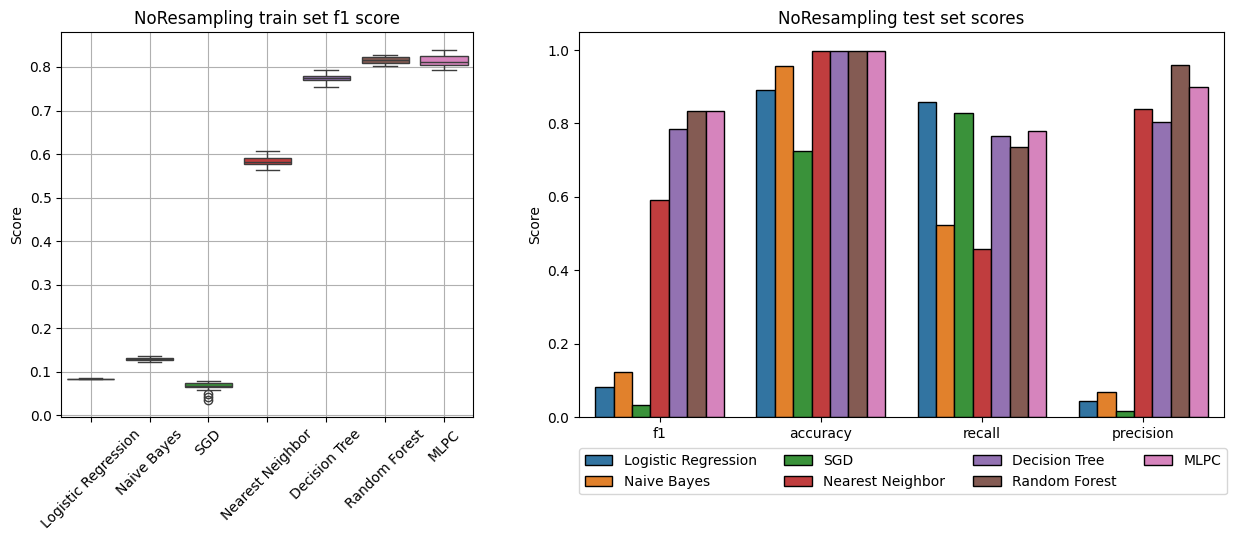

### Nearest Neighbor

Baseline scores for Nearest Neighbor:

In [13]:
stats[stats['model'] == 'Nearest Neighbor']

,model,iteration,f1_train,f1_test,accuracy_test
0,Nearest Neighbor,0,0.583369,0.597887,0.994481


In [14]:
params = [{
            'n_neighbors': range(2, 7),
            'metric': ['euclidean', 'manhattan', 'minkowski'],
            'weights': ['uniform', 'distance']
          }]

gs = gs_cv('Nearest Neighbor', 1, KNeighborsClassifier(), params, n_jobs=1, search_type = 'halving')

Time: 3.5266666666666664
Best params: {'metric': 'minkowski', 'n_neighbors': 4, 'weights': 'distance'}
Train set f1: 0.6459631141391539
Test set f1: 0.6489637305699483
Test set accuracy: 0.9966560652005589


In [15]:
params = [{
            'n_neighbors': range(3, 6),
            'metric': ['euclidean', 'manhattan', 'minkowski'],
            'weights': ['uniform', 'distance']
          }]

gs = gs_cv('Nearest Neighbor', 2, KNeighborsClassifier(), params, n_jobs=1, search_type = 'grid')

Time: 9.999444444444444
Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Train set f1: 0.6629428276062367
Test set f1: 0.6874606175173283
Test set accuracy: 0.9969398677850134


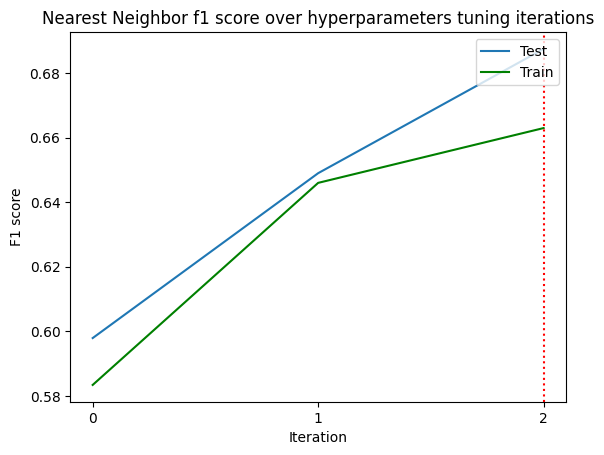

Confusion matrix:
[[322124    168]
 [   932    945]] 

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    322292
       Fraud       0.85      0.50      0.63      1877

    accuracy                           1.00    324169
   macro avg       0.92      0.75      0.82    324169
weighted avg       1.00      1.00      1.00    324169



In [11]:
tuneplot('Nearest Neighbor')

### Decision Tree

Baseline scores for Decision Tree:

In [84]:
stats[stats['model'] == 'Decision Tree']

,model,iteration,f1_train,f1_test,accuracy_test
1,Decision Tree,0,0.773412,0.784026,0.997548


In [20]:
dec_tree = DecisionTreeClassifier(random_state=1, class_weight='balanced').fit(X_train, y_train)

pred = dec_tree.predict(X_test)
print(f1_score(y_test, pred))
print(accuracy_score(y_test, pred))
print('Decision tree depth:', dec_tree.get_depth())

0.7842923370602672
0.9975599147358323
Decision tree depth: 104


In [17]:
params = [{
            'min_samples_split': np.linspace(2, 40, 5).astype(int),
            'min_samples_leaf': np.linspace(1, 40, 5).astype(int)
          }]

gs = gs_cv('Decision Tree', 1, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='halving')

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 108056
max_resources_: 972506
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 25
n_resources: 108056
Fitting 50 folds for each of 25 candidates, totalling 1250 fits
----------
iter: 1
n_candidates: 9
n_resources: 324168
Fitting 50 folds for each of 9 candidates, totalling 450 fits
----------
iter: 2
n_candidates: 3
n_resources: 972504
Fitting 50 folds for each of 3 candidates, totalling 150 fits
Best params: {'min_samples_leaf': 1, 'min_samples_split': 2}

Time: 0.40194444444444444
Best params: {'min_samples_leaf': 1, 'min_samples_split': 2}
		   TP/TN/FP/FN
Train set stats(n): 5629 966877 0 0
Train set stats(%): 1.0 1.0 0.0 0.0
Test set stats(n): 1438 321940 352 439
Test set stats(%): 0.7661161427810336 0.9989078227197696 0.0010921772802303502 0.23388385721896643 

Train set cv mean f1: 0.7723714115005247
Train set f1: 1.0
Test set f1: 0.7842923370602672
Train set accuracy: 1.0
Te

In [18]:
gs.best_estimator_.get_depth()

104

In [23]:
params = [{
            'min_samples_split': range(2, 5),
            'min_samples_leaf': range(1, 5),
            'max_depth': range(90, 106, 5)
          }]

gs = gs_cv('Decision Tree', 2, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Fitting 50 folds for each of 48 candidates, totalling 2400 fits
Best params: {'max_depth': 105, 'min_samples_leaf': 1, 'min_samples_split': 2}

Time: 3.315833333333333
Best params: {'max_depth': 105, 'min_samples_leaf': 1, 'min_samples_split': 2}
		   TP/TN/FP/FN
Train set stats(n): 5629 966877 0 0
Train set stats(%): 1.0 1.0 0.0 0.0
Test set stats(n): 1438 321940 352 439
Test set stats(%): 0.7661161427810336 0.9989078227197696 0.0010921772802303502 0.23388385721896643 

Train set cv mean f1: 0.7715967179397006
Train set f1: 1.0
Test set f1: 0.7842923370602672
Train set accuracy: 1.0
Test set accuracy: 0.9975599147358323


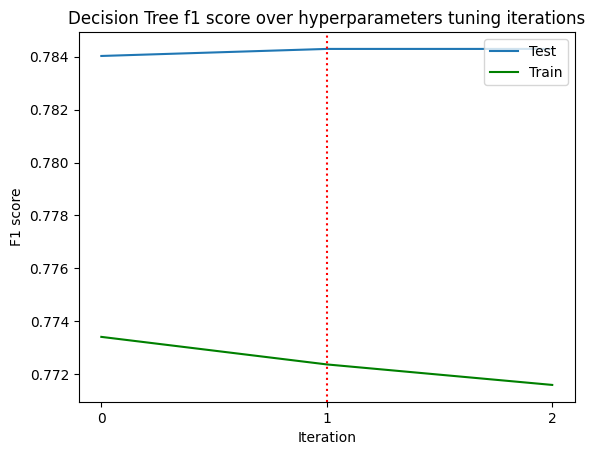

Confusion matrix:
[[321857    435]
 [   445   1432]] 

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    322292
       Fraud       0.77      0.76      0.76      1877

    accuracy                           1.00    324169
   macro avg       0.88      0.88      0.88    324169
weighted avg       1.00      1.00      1.00    324169



In [190]:
tuneplot('Decision Tree')

### Random Forest

Baseline scores for Random Forest:

In [85]:
stats[stats['model'] == 'Random Forest']

,model,iteration,f1_train,f1_test,accuracy_test
2,Random Forest,0,0.816901,0.850991,0.998399


In [29]:
forest = RandomForestClassifier(random_state=1, class_weight='balanced').fit(X_train, y_train)

array([ 100,  575, 1050, 1525, 2000])

In [ ]:
#start approx 13 53
params = [{
            'n_estimators': np.linspace(100, 2000, 5).astype(int),  
            'min_samples_split': np.linspace(5, 40, 5).astype(int),
            'min_samples_leaf': np.linspace(5, 20, 5).astype(int)
          }]

halving_gs_cv('forest_1', RandomForestClassifier(random_state=1), params, n_jobs=12)

#iter: 0
#n_candidates: 13718


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 23873
max_resources_: 1933754
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 125
n_resources: 23873
Fitting 50 folds for each of 125 candidates, totalling 6250 fits
----------
iter: 1
n_candidates: 42
n_resources: 71619
Fitting 50 folds for each of 42 candidates, totalling 2100 fits
----------
iter: 2
n_candidates: 14
n_resources: 214857
Fitting 50 folds for each of 14 candidates, totalling 700 fits
----------
iter: 3
n_candidates: 5
n_resources: 644571
Fitting 50 folds for each of 5 candidates, totalling 250 fits


In [ ]:

            'max_depth': range(10, 100, 10),

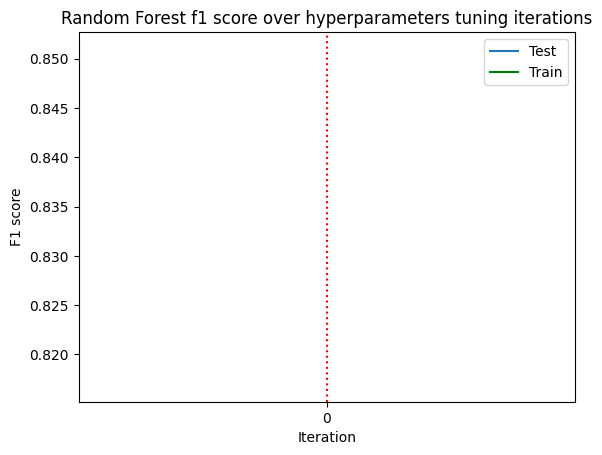

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\dfskl\\Jupyter notebooks\\kaggle\\Credit-Card-Transactions-Fraud-Detection\\saves\\models_training\\Random Forest_0.pkl'

In [184]:
tuneplot('Random Forest')

### MLPC

Baseline scores for MLPC:

In [86]:
stats[stats['model'] == 'MLPC']

,model,iteration,f1_train,f1_test,accuracy_test
3,MLPC,0,0.814235,0.835046,0.996462


At first I will test different hidden layers configurations to find a limit either by overfitting or by training time.

In [16]:
params = [{
            'hidden_layer_sizes': [(100, 100, 100, 100, 100, 100)]
          }]

gs = gs_cv('MLPC', 1, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 3.2380555555555555
Best params: {'hidden_layer_sizes': (100, 100, 100, 100, 100, 100)}
Train set f1: 0.8222189119475257
Test set f1: 0.8432276657060519
Test set accuracy: 0.9983218629788783


The model, trained above, used significant amount of time to train, so tuning other hyperparameters will take even more time. That's why I consider model of this complexity a limit for current project<br/>
Now I will try other configurations of hidden layers to get better training time.

In [24]:
params = [{
            'hidden_layer_sizes': [(100, 100, 100, 100)]
          }]

gs = gs_cv('MLPC', 2, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 2.044166666666667
Best params: {'hidden_layer_sizes': (100, 100, 100, 100)}
Train set f1: 0.8174570613875237
Test set f1: 0.8395629672225418
Test set accuracy: 0.99827867562907


In [25]:
params = [{
            'hidden_layer_sizes': [(60, 60, 60, 60)]
          }]

gs = gs_cv('MLPC', 3, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.9975
Best params: {'hidden_layer_sizes': (60, 60, 60, 60)}
Train set f1: 0.8176566200841083
Test set f1: 0.839673147365455
Test set accuracy: 0.9982447427113635


In [33]:
params = [{
            'hidden_layer_sizes': [(60, 60, 60, 60, 60, 60)]
          }]

gs = gs_cv('MLPC', 4, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.6022222222222224
Best params: {'hidden_layer_sizes': (60, 60, 60, 60, 60, 60)}
Train set f1: 0.8172071109902491
Test set f1: 0.8325517241379311
Test set accuracy: 0.998127519904741


In [27]:
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30)]
          }]

gs = gs_cv('MLPC', 5, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.3236111111111111
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30)}
Train set f1: 0.8220253973378729
Test set f1: 0.8402836879432625
Test set accuracy: 0.9982632515755671


In [28]:
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('MLPC', 6, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.4066666666666666
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30)}
Train set f1: 0.8220257309160268
Test set f1: 0.8330025517436915
Test set accuracy: 0.9981830464973517


In [29]:
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('MLPC', 7, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.47555555555555556
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30)}
Train set f1: 0.821044233208442
Test set f1: 0.824838898652607
Test set accuracy: 0.9981552832010464


In [30]:
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('MLPC', 8, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.6052777777777778
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30)}
Train set f1: 0.8225265928469858
Test set f1: 0.8455377574370709
Test set accuracy: 0.9983342022216807


In [31]:
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('MLPC', 9, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.6275
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30)}
Train set f1: 0.8228622201164825
Test set f1: 0.830654420206659
Test set accuracy: 0.9981799616866511


In [32]:
params = [{
            'hidden_layer_sizes': [(60, 30, 60, 30, 60, 30)]
          }]

gs = gs_cv('MLPC', 10, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.2169444444444444
Best params: {'hidden_layer_sizes': (60, 30, 60, 30, 60, 30)}
Train set f1: 0.8179746604240745
Test set f1: 0.8421652421652421
Test set accuracy: 0.9982910148718724


In [34]:
params = [{
            'hidden_layer_sizes': [(30, 15, 30, 15, 30, 15)]
          }]

gs = gs_cv('MLPC', 11, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.2930555555555555
Best params: {'hidden_layer_sizes': (30, 15, 30, 15, 30, 15)}
Train set f1: 0.822440505001261
Test set f1: 0.8301776871540926
Test set accuracy: 0.9982015553615552


In [35]:
params = [{
            'hidden_layer_sizes': [(60, 30, 45, 30, 45, 30)]
          }]

gs = gs_cv('MLPC', 12, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.005277777777778
Best params: {'hidden_layer_sizes': (60, 30, 45, 30, 45, 30)}
Train set f1: 0.8211859729748029
Test set f1: 0.83451536643026
Test set accuracy: 0.9982725060076688


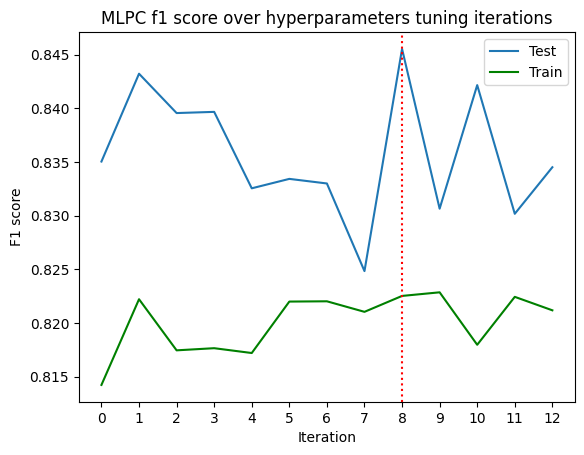

Confusion matrix:
[[322120    172]
 [   429   1448]] 

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    322292
       Fraud       0.89      0.77      0.83      1877

    accuracy                           1.00    324169
   macro avg       0.95      0.89      0.91    324169
weighted avg       1.00      1.00      1.00    324169



In [55]:
tuneplot('MLPC')

Iteration 8 with hidden layers configuration (30, 30, 30, 30, 30, 30, 30, 30) showed the best results, so for this configuration other hyperparameters will be searched.

In [91]:
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30, 30)],
            'activation': ['tanh', 'relu'],
            'solver': ['sgd', 'adam'],
            'alpha': np.linspace(0.0001, 0.1, 5),
            'learning_rate': ['constant', 'adaptive']
          }]

gs = gs_cv('MLPC', 13, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='halving')

Best params: {'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30), 'learning_rate': 'adaptive', 'solver': 'sgd'}

Time: 6.065555555555556
Best params: {'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30), 'learning_rate': 'adaptive', 'solver': 'sgd'}
Train set f1: 0.8043095379911194
Test set f1: 0.806201550387597
Test set accuracy: 0.9979948730446156


Unfortunately halving grid search doesn't work well here, so the parameters should be tuned separately.

In [ ]:
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30, 30)],
            'activation': ['tanh', 'relu']
          }]

gs = gs_cv('MLPC', 14, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 2 candidates, totalling 100 fits


### Final pipeline

In [ ]:
best_model = joblib.load(cur_dir + '\\saves\\models_training\\mlpc__7.pkl').best_estimator_
pipe.steps.append(['mlpc', best_model])
    
#pipe

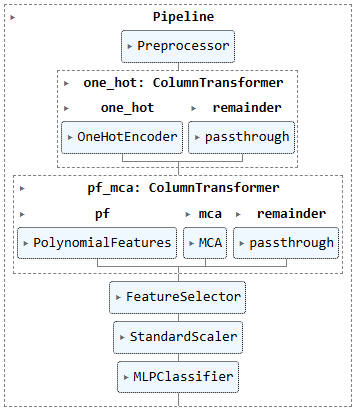

In [170]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1, stratify=y)

pred = pipe.predict(X_test)

print('Pipeline prediction f1:', f1_score(y_test, pred))
print('Pipeline prediction accuracy:', accuracy_score(y_test, pred))

stats[(stats['model'] == 'mlpc_') & (stats['iteration'] == 7)]

Pipeline prediction f1: 0.8281384043465828
Pipeline prediction accuracy: 0.9981460287689446


,model,iteration,f1_train,f1_test,accuracy_test
14,mlpc_,7,0.822527,0.845538,0.998334


In [173]:
with open(cur_dir + '\\saves\\prediction_pipeline.dill', 'wb') as file:
    dill.dump(pipe, file)

### Grand test

In [175]:
with open(cur_dir + '\\saves\\prediction_pipeline.dill', 'rb') as file:
    pipe_test = dill.load(file)

pipe_test_df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
pipe_test_y = pipe_test_df['is_fraud']
pipe_test_df.drop(columns='is_fraud', inplace=True)

pipe_test_pred = pipe_test.predict(pipe_test_df)

print('Pipeline prediction f1:', f1_score(pipe_test_y, pipe_test_pred))
print('Pipeline prediction accuracy:', accuracy_score(pipe_test_y, pipe_test_pred))

Pipeline prediction f1: 0.8408472878202375
Pipeline prediction accuracy: 0.9982848439277383


# DELETE

In [54]:
model = 'MLPC'
stats.loc[(stats['model'] == model) & (stats['iteration'] == 0), 'f1_train'] = stats_bkp.loc[(stats_bkp['model'] == model) & (stats_bkp['iteration'] == 0), 'f1_train'].item()